# 🏦 BankChurners — Prédiction Attrition Client
### Apprentissage Supervisé — Classification
**Cours A. Larhlimi — Mars 2026**

---
**Objectif :** Prédire si un client va churner (`Attrited Customer`) à partir de ses caractéristiques bancaires.

**Pipeline :**
1. EDA & Preprocessing  
2. Baseline : Régression Logistique + Naive Bayes  
3. KNN, SVM, Decision Tree  
4. Random Forest + Gradient Boosting  
5. MLP (Réseau de Neurones)  
6. Comparaison & métriques  
7. Feature Importance & Interprétabilité

## 0. Imports & Configuration

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    accuracy_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline

print("✅ Imports OK")

✅ Imports OK


## 1. Chargement & Exploration des Données (EDA)
Le dataset **BankChurners** contient **10 127 clients** avec 21 features.  
La variable cible `Attrition_Flag` indique si un client a quitté la banque.

In [15]:
df = pd.read_csv('/content/BankChurners.csv.zip')

# Supprimer colonnes inutiles
df.drop(columns=[
    'CLIENTNUM',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
], inplace=True)

print(f"Shape : {df.shape}")
print(f"\n🎯 Distribution de la cible :")
print(df['Attrition_Flag'].value_counts())
print(f"\nPourcentages :")
print(df['Attrition_Flag'].value_counts(normalize=True).round(3) * 100)

Shape : (10127, 20)

🎯 Distribution de la cible :
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Pourcentages :
Attrition_Flag
Existing Customer    83.9
Attrited Customer    16.1
Name: proportion, dtype: float64


In [16]:
# Aperçu du dataset
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [17]:
# Statistiques descriptives
df.describe().round(2)

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00
mean,46.33,2.35,35.93,3.81,2.34,2.46,8631.95,1162.81,7469.14,0.76,4404.09,64.86,0.71,0.27
std,8.02,1.30,7.99,1.55,1.01,1.11,9088.78,814.99,9090.69,0.22,3397.13,23.47,0.24,0.28
min,26.00,0.00,13.00,1.00,0.00,0.00,1438.30,0.00,3.00,0.00,510.00,10.00,0.00,0.00
25%,41.00,1.00,31.00,3.00,2.00,2.00,2555.00,359.00,1324.50,0.63,2155.50,45.00,0.58,0.02
50%,46.00,2.00,36.00,4.00,2.00,2.00,4549.00,1276.00,3474.00,0.74,3899.00,67.00,0.70,0.18
75%,52.00,3.00,40.00,5.00,3.00,3.00,11067.50,1784.00,9859.00,0.86,4741.00,81.00,0.82,0.50
max,73.00,5.00,56.00,6.00,6.00,6.00,34516.00,2517.00,34516.00,3.40,18484.00,139.00,3.71,1.00


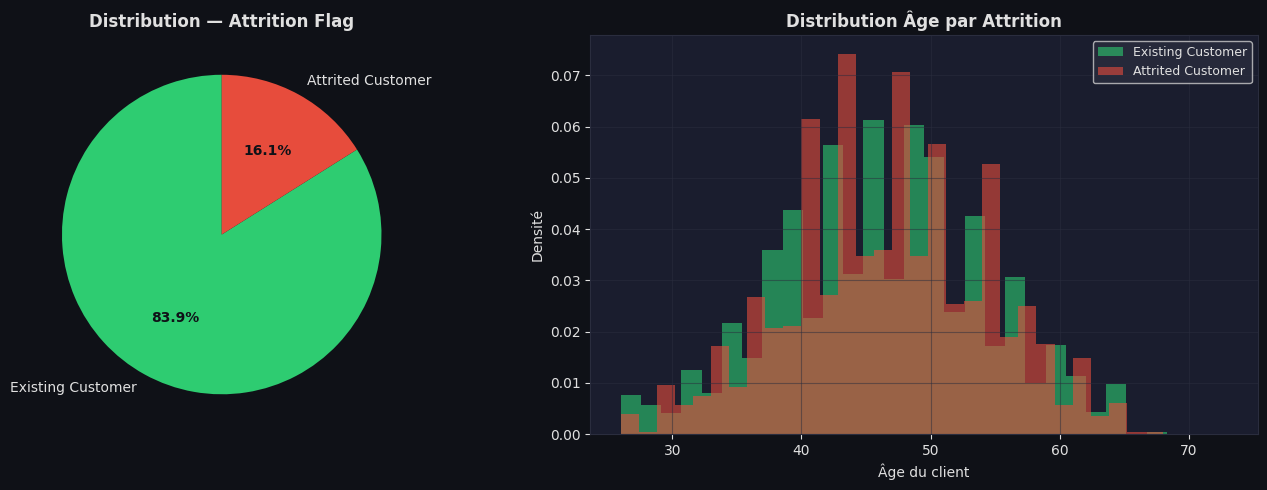

In [18]:
# EDA — Visualisation de la distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

# Pie chart
ax = axes[0]
ax.set_facecolor('#1a1d2e')
counts = df['Attrition_Flag'].value_counts()
colors_pie = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index,
    colors=colors_pie, autopct='%1.1f%%', startangle=90,
    textprops={'color': '#e0e0e0', 'fontsize': 10}
)
for at in autotexts:
    at.set_color('#0f1117'); at.set_fontweight('bold')
ax.set_title('Distribution — Attrition Flag', color='#e0e0e0', fontsize=12, fontweight='bold')

# Histogramme Age par Attrition
ax2 = axes[1]
ax2.set_facecolor('#1a1d2e')
for label, color in [('Existing Customer', '#2ecc71'), ('Attrited Customer', '#e74c3c')]:
    subset = df[df['Attrition_Flag'] == label]['Customer_Age']
    ax2.hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
ax2.set_xlabel('Âge du client', color='#e0e0e0')
ax2.set_ylabel('Densité', color='#e0e0e0')
ax2.set_title('Distribution Âge par Attrition', color='#e0e0e0', fontsize=12, fontweight='bold')
ax2.tick_params(colors='#e0e0e0')
ax2.legend(fontsize=9, facecolor='#2a2d3e', labelcolor='#e0e0e0')
for spine in ax2.spines.values(): spine.set_edgecolor('#2a2d3e')
ax2.grid(color='#2a2d3e', alpha=0.5)

plt.tight_layout()
plt.show()

## 2. Preprocessing

Selon les **bonnes pratiques du cours** :
- Encoder les variables catégorielles
- Normaliser **après** le split (éviter le *data leakage*)
- Utiliser un split **stratifié** (classes déséquilibrées)
- Appliquer `StandardScaler` pour SVM, KNN, Logistique, MLP

In [19]:
# Encodage de la cible
df['Target'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)
df.drop(columns=['Attrition_Flag'], inplace=True)

# Encodage LabelEncoder des variables catégorielles
cat_cols = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(f"✅ {len(cat_cols)} variables encodées : {cat_cols}")
print(f"✅ Valeurs manquantes : {df.isnull().sum().sum()}")
print(f"✅ Shape finale : {df.shape}")

✅ 5 variables encodées : ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
✅ Valeurs manquantes : 0
✅ Shape finale : (10127, 20)


In [20]:
# Séparation features / cible
X = df.drop(columns=['Target'])
y = df['Target']

# Split stratifié 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Ratio churn train : {y_train.mean():.3f}  |  test : {y_test.mean():.3f}")

# Normalisation (APRÈS le split — évite le data leakage !)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit sur train uniquement
X_test_sc  = scaler.transform(X_test)         # transform sur test

# Cross-validation stratifiée 5-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\n✅ Preprocessing terminé")

Train : (8101, 19)  |  Test : (2026, 19)
Ratio churn train : 0.161  |  test : 0.160

✅ Preprocessing terminé


In [21]:
# Dictionnaire pour stocker tous les résultats
results = {}

## 3. Baseline — Régression Logistique
> *"Toujours commencer par une régression logistique comme baseline."* — cours A. Larhlimi

Modélise P(y=1|x) via la fonction sigmoïde. Frontière de décision **linéaire**.  
Interprétable : coefficients = log-odds. Fournit des probabilités calibrées.

In [22]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr  = lr.predict(X_test_sc)
y_proba_lr = lr.predict_proba(X_test_sc)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
cv_lr  = cross_val_score(lr, X_train_sc, y_train, cv=skf, scoring='roc_auc').mean()

results['Régression Logistique'] = {'Accuracy': acc_lr, 'F1': f1_lr, 'AUC-ROC': auc_lr, 'CV AUC': cv_lr}
print(f"Accuracy  : {acc_lr:.4f}")
print(f"F1-Score  : {f1_lr:.4f}")
print(f"AUC-ROC   : {auc_lr:.4f}")
print(f"CV AUC    : {cv_lr:.4f} (5-fold StratifiedKFold)")

Accuracy  : 0.9018
F1-Score  : 0.6349
AUC-ROC   : 0.9117
CV AUC    : 0.9243 (5-fold StratifiedKFold)


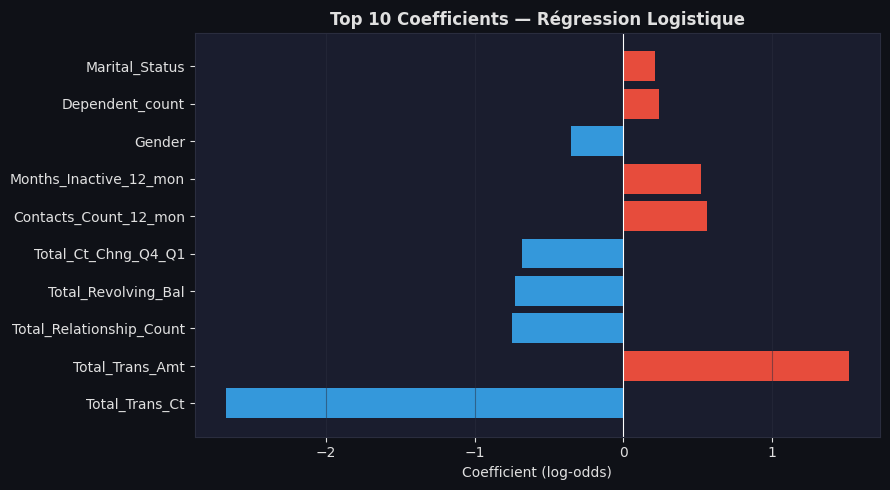

In [23]:
# Coefficients les plus importants
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')
colors_coef = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef, edgecolor='none')
ax.axvline(0, color='white', linewidth=0.8)
ax.set_title('Top 10 Coefficients — Régression Logistique', color='#e0e0e0', fontsize=12, fontweight='bold')
ax.tick_params(colors='#e0e0e0')
ax.set_xlabel('Coefficient (log-odds)', color='#e0e0e0')
for spine in ax.spines.values(): spine.set_edgecolor('#2a2d3e')
ax.grid(axis='x', color='#2a2d3e', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Naive Bayes (GaussianNB)
Hypothèse : features **indépendantes** conditionnellement à la classe.  
`P(y|x₁...xₚ) ∝ P(y) × Π P(xⱼ|y)`  
Très rapide, fonctionne bien avec peu de données.

In [24]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_sc, y_train)

y_pred_nb  = nb.predict(X_test_sc)
y_proba_nb = nb.predict_proba(X_test_sc)[:, 1]

acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb  = f1_score(y_test, y_pred_nb)
auc_nb = roc_auc_score(y_test, y_proba_nb)
cv_nb  = cross_val_score(nb, X_train_sc, y_train, cv=skf, scoring='roc_auc').mean()

results['Naive Bayes'] = {'Accuracy': acc_nb, 'F1': f1_nb, 'AUC-ROC': auc_nb, 'CV AUC': cv_nb}
print(f"Accuracy  : {acc_nb:.4f}")
print(f"F1-Score  : {f1_nb:.4f}")
print(f"AUC-ROC   : {auc_nb:.4f}")
print(f"CV AUC    : {cv_nb:.4f}")

Accuracy  : 0.8806
F1-Score  : 0.6159
AUC-ROC   : 0.8415
CV AUC    : 0.8765


## 5. KNN Classification
Classe majoritaire des k plus proches voisins (distance euclidienne).  
**Lazy learner** — pas d'entraînement, prédiction O(n).  
⚠️ Nécessite normalisation. Choisir k par cross-validation.

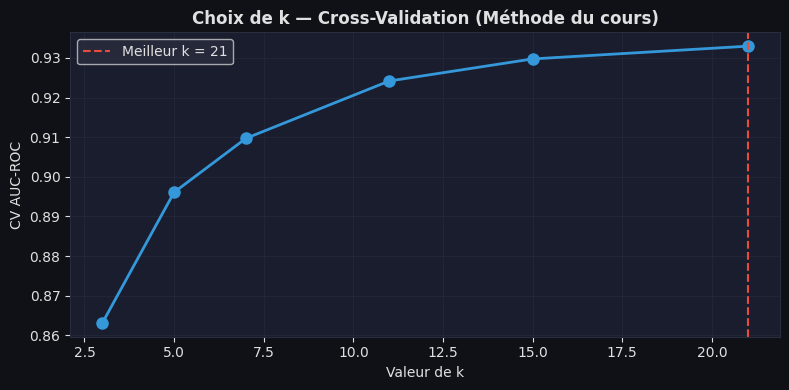

Meilleur k = 21


In [25]:
from sklearn.neighbors import KNeighborsClassifier

# Sélection du meilleur k par cross-validation
k_values = [3, 5, 7, 11, 15, 21]
cv_scores_k = [
    cross_val_score(KNeighborsClassifier(n_neighbors=k),
                    X_train_sc, y_train, cv=skf, scoring='roc_auc').mean()
    for k in k_values
]

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')
ax.plot(k_values, cv_scores_k, 'o-', color='#3498db', linewidth=2, markersize=8)
best_k = k_values[np.argmax(cv_scores_k)]
ax.axvline(best_k, color='#e74c3c', linestyle='--', label=f'Meilleur k = {best_k}')
ax.set_xlabel('Valeur de k', color='#e0e0e0')
ax.set_ylabel('CV AUC-ROC', color='#e0e0e0')
ax.set_title('Choix de k — Cross-Validation (Méthode du cours)', color='#e0e0e0', fontsize=12, fontweight='bold')
ax.tick_params(colors='#e0e0e0')
ax.legend(facecolor='#2a2d3e', labelcolor='#e0e0e0')
for spine in ax.spines.values(): spine.set_edgecolor('#2a2d3e')
ax.grid(color='#2a2d3e', alpha=0.5)
plt.tight_layout()
plt.show()
print(f"Meilleur k = {best_k}")

In [26]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_sc, y_train)

y_pred_knn  = knn.predict(X_test_sc)
y_proba_knn = knn.predict_proba(X_test_sc)[:, 1]

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn  = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)
cv_knn  = max(cv_scores_k)

results['KNN'] = {'Accuracy': acc_knn, 'F1': f1_knn, 'AUC-ROC': auc_knn, 'CV AUC': cv_knn}
print(f"Accuracy  : {acc_knn:.4f}")
print(f"F1-Score  : {f1_knn:.4f}")
print(f"AUC-ROC   : {auc_knn:.4f}")
print(f"CV AUC    : {cv_knn:.4f}")

Accuracy  : 0.8929
F1-Score  : 0.5526
AUC-ROC   : 0.9207
CV AUC    : 0.9329


## 6. SVM — Support Vector Machine (kernel RBF)
Hyperplan à **marge maximale**. Kernel RBF : `K(x,y) = exp(−γ‖x−y‖²)`.  
`C` grand → faible régularisation. `probability=True` → Platt scaling pour les probas.  
⚠️ Complexité O(n²–n³) → lent sur grands datasets.

In [27]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm.fit(X_train_sc, y_train)

y_pred_svm  = svm.predict(X_test_sc)
y_proba_svm = svm.predict_proba(X_test_sc)[:, 1]

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_proba_svm)
cv_svm  = cross_val_score(svm, X_train_sc, y_train, cv=skf, scoring='roc_auc').mean()

results['SVM (RBF)'] = {'Accuracy': acc_svm, 'F1': f1_svm, 'AUC-ROC': auc_svm, 'CV AUC': cv_svm}
print(f"Accuracy  : {acc_svm:.4f}")
print(f"F1-Score  : {f1_svm:.4f}")
print(f"AUC-ROC   : {auc_svm:.4f}")
print(f"CV AUC    : {cv_svm:.4f}")

Accuracy  : 0.9284
F1-Score  : 0.7406
AUC-ROC   : 0.9556
CV AUC    : 0.9644


## 7. Decision Tree (avec Pruning)
Partitionne l'espace récursivement selon le critère **Gini** : `Gini = 1 − Σpᵢ²`  
**Pre-pruning** via `max_depth` et `min_samples_leaf` pour éviter l'overfitting.  
✅ Pas de normalisation nécessaire. Très interprétable.

In [28]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    criterion='gini',
    random_state=42
)
dt.fit(X_train, y_train)   # Pas besoin de StandardScaler

y_pred_dt  = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)
cv_dt  = cross_val_score(dt, X, y, cv=skf, scoring='roc_auc').mean()

results['Decision Tree'] = {'Accuracy': acc_dt, 'F1': f1_dt, 'AUC-ROC': auc_dt, 'CV AUC': cv_dt}
print(f"Accuracy  : {acc_dt:.4f}")
print(f"F1-Score  : {f1_dt:.4f}")
print(f"AUC-ROC   : {auc_dt:.4f}")
print(f"CV AUC    : {cv_dt:.4f}")

Accuracy  : 0.9339
F1-Score  : 0.7825
AUC-ROC   : 0.9574
CV AUC    : 0.9584


## 8. Random Forest
**Bagging** : chaque arbre entraîné sur ~63% des données (avec remise).  
**Feature randomness** : sous-ensemble aléatoire de features à chaque split → √p features.  
**OOB Error** : estimation gratuite sur les 37% non vus par chaque arbre.  
`class_weight='balanced'` pour compenser le déséquilibre des classes.

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',   # Gère le déséquilibre 83%/17%
    n_jobs=-1,
    oob_score=True,            # Estimation OOB gratuite
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
cv_rf  = cross_val_score(rf, X, y, cv=skf, scoring='roc_auc').mean()

results['Random Forest'] = {'Accuracy': acc_rf, 'F1': f1_rf, 'AUC-ROC': auc_rf, 'CV AUC': cv_rf}
print(f"OOB Score : {rf.oob_score_:.4f}  ← estimation gratuite")
print(f"Accuracy  : {acc_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")
print(f"AUC-ROC   : {auc_rf:.4f}")
print(f"CV AUC    : {cv_rf:.4f}")

OOB Score : 0.9543  ← estimation gratuite
Accuracy  : 0.9467
F1-Score  : 0.8402
AUC-ROC   : 0.9828
CV AUC    : 0.9859


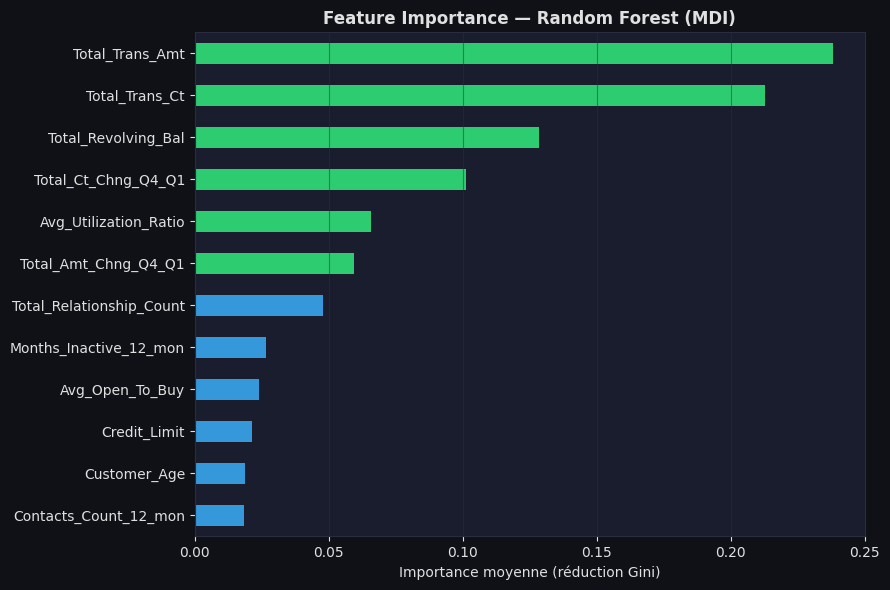

In [30]:
# Feature Importance — Random Forest (MDI)
feat_imp_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')
colors_fi = ['#2ecc71' if v > feat_imp_rf.median() else '#3498db' for v in feat_imp_rf.values]
feat_imp_rf.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='none')
ax.set_title('Feature Importance — Random Forest (MDI)', color='#e0e0e0', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance moyenne (réduction Gini)', color='#e0e0e0')
ax.tick_params(colors='#e0e0e0')
for spine in ax.spines.values(): spine.set_edgecolor('#2a2d3e')
ax.grid(axis='x', color='#2a2d3e', alpha=0.5)
plt.tight_layout()
plt.show()

## 9. Gradient Boosting (GBM)
Construit des arbres **séquentiellement** : `F_m(x) = F_{m-1}(x) + η × h_m(x)`  
Chaque arbre corrige les résidus du précédent (gradient du log-loss).  
> *"Gradient Boosting = meilleur choix par défaut sur données tabulaires."* — cours A. Larhlimi

Paramètres clés :
- `learning_rate` (η) : taille des pas
- `n_estimators` : nombre d'arbres
- `max_depth` : profondeur de chaque arbre
- `subsample` : fraction de données utilisées (stochastic boosting)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=42
)
gbm.fit(X_train, y_train)

y_pred_gbm  = gbm.predict(X_test)
y_proba_gbm = gbm.predict_proba(X_test)[:, 1]

acc_gbm = accuracy_score(y_test, y_pred_gbm)
f1_gbm  = f1_score(y_test, y_pred_gbm)
auc_gbm = roc_auc_score(y_test, y_proba_gbm)
cv_gbm  = cross_val_score(gbm, X, y, cv=skf, scoring='roc_auc').mean()

results['Gradient Boosting'] = {'Accuracy': acc_gbm, 'F1': f1_gbm, 'AUC-ROC': auc_gbm, 'CV AUC': cv_gbm}
print(f"Accuracy  : {acc_gbm:.4f}")
print(f"F1-Score  : {f1_gbm:.4f}")
print(f"AUC-ROC   : {auc_gbm:.4f}")
print(f"CV AUC    : {cv_gbm:.4f}")

In [ ]:
# Feature Importance — Gradient Boosting
feat_imp_gbm = pd.Series(gbm.feature_importances_, index=X.columns).sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')
colors_gbm = ['#e74c3c' if v > feat_imp_gbm.median() else '#f39c12' for v in feat_imp_gbm.values]
feat_imp_gbm.plot(kind='barh', ax=ax, color=colors_gbm, edgecolor='none')
ax.set_title('Feature Importance — Gradient Boosting', color='#e0e0e0', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance', color='#e0e0e0')
ax.tick_params(colors='#e0e0e0')
for spine in ax.spines.values(): spine.set_edgecolor('#2a2d3e')
ax.grid(axis='x', color='#2a2d3e', alpha=0.5)
plt.tight_layout()
plt.show()

## 10. MLP — Réseau de Neurones
`h⁽ˡ⁾ = σ(W⁽ˡ⁾ h⁽ˡ⁻¹⁾ + b⁽ˡ⁾)` avec activation ReLU.  
Architecture : **128 → 64 → 32 → Sigmoid** (classification binaire).  
Régularisation : `alpha` (L2 weight decay) + **Early Stopping** (arrêt automatique).  
⚠️ Nécessite normalisation et beaucoup de données.

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # Architecture : 3 couches cachées
    activation='relu',                  # ReLU pour couches cachées
    solver='adam',                      # Optimiseur Adam
    alpha=0.001,                        # L2 weight decay (régularisation)
    batch_size=64,
    learning_rate='adaptive',
    max_iter=300,
    early_stopping=True,                # Arrêt si validation loss stagne
    validation_fraction=0.1,
    random_state=42
)
mlp.fit(X_train_sc, y_train)

y_pred_mlp  = mlp.predict(X_test_sc)
y_proba_mlp = mlp.predict_proba(X_test_sc)[:, 1]

acc_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp  = f1_score(y_test, y_pred_mlp)
auc_mlp = roc_auc_score(y_test, y_proba_mlp)
cv_mlp  = cross_val_score(mlp, X_train_sc, y_train, cv=skf, scoring='roc_auc').mean()

results['MLP'] = {'Accuracy': acc_mlp, 'F1': f1_mlp, 'AUC-ROC': auc_mlp, 'CV AUC': cv_mlp}
print(f"Itérations : {mlp.n_iter_} (early stopping)")
print(f"Accuracy  : {acc_mlp:.4f}")
print(f"F1-Score  : {f1_mlp:.4f}")
print(f"AUC-ROC   : {auc_mlp:.4f}")
print(f"CV AUC    : {cv_mlp:.4f}")

## 11. Gestion du Déséquilibre — Seuil de Décision Optimal
> *"Avec des classes déséquilibrées (83%/17%), utiliser F1-Score & AUC-ROC plutôt que l'Accuracy."* — cours

Le seuil par défaut (0.5) n'est pas optimal. On peut l'ajuster pour maximiser le F1.

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores_thresh  = [f1_score(y_test, (y_proba_rf >= t).astype(int)) for t in thresholds]
rec_scores_thresh = [recall_score(y_test, (y_proba_rf >= t).astype(int)) for t in thresholds]
prec_scores_thresh= [precision_score(y_test, (y_proba_rf >= t).astype(int), zero_division=0) for t in thresholds]

best_thresh = thresholds[np.argmax(f1_scores_thresh)]
y_pred_rf_opt = (y_proba_rf >= best_thresh).astype(int)

results['RF (seuil optimal)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf_opt),
    'F1': max(f1_scores_thresh),
    'AUC-ROC': auc_rf,
    'CV AUC': cv_rf
}

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')
ax.plot(thresholds, f1_scores_thresh,   color='#2ecc71', lw=2, label='F1-Score')
ax.plot(thresholds, prec_scores_thresh, color='#3498db', lw=2, label='Précision')
ax.plot(thresholds, rec_scores_thresh,  color='#e74c3c', lw=2, label='Rappel')
ax.axvline(best_thresh, color='#f39c12', lw=1.5, ls='--', label=f'Seuil optimal = {best_thresh:.2f}')
ax.axvline(0.5, color='white', lw=1, ls=':', alpha=0.6, label='Seuil 0.5 (défaut)')
ax.set_xlabel('Seuil de décision', color='#e0e0e0')
ax.set_ylabel('Score', color='#e0e0e0')
ax.set_title('Précision / Rappel / F1 en fonction du Seuil — Random Forest', color='#e0e0e0', fontsize=12, fontweight='bold')
ax.tick_params(colors='#e0e0e0')
ax.legend(facecolor='#2a2d3e', labelcolor='#e0e0e0')
for spine in ax.spines.values(): spine.set_edgecolor('#2a2d3e')
ax.grid(color='#2a2d3e', alpha=0.5)
plt.tight_layout()
plt.show()
print(f"Seuil par défaut (0.5) : F1 = {f1_rf:.4f}")
print(f"Seuil optimal ({best_thresh:.2f})     : F1 = {max(f1_scores_thresh):.4f}")

## 12. Tableau Comparatif — Tous les Modèles

In [ ]:
df_results = pd.DataFrame(results).T.sort_values('AUC-ROC', ascending=False)
df_results = df_results.round(4)
print("=" * 60)
print("  TABLEAU COMPARATIF DES MODÈLES")
print("=" * 60)
print(df_results.to_string())
df_results

## 13. Visualisations Comparatives

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#0f1117')
TXT_C = '#e0e0e0'; GRID_C = '#2a2d3e'

def style_ax(ax, title):
    ax.set_facecolor('#1a1d2e')
    ax.tick_params(colors=TXT_C, labelsize=9)
    ax.xaxis.label.set_color(TXT_C)
    ax.yaxis.label.set_color(TXT_C)
    ax.set_title(title, color=TXT_C, fontsize=11, fontweight='bold', pad=8)
    for spine in ax.spines.values(): spine.set_edgecolor(GRID_C)
    ax.grid(True, color=GRID_C, linewidth=0.5, alpha=0.7)

# ── AUC-ROC comparaison ──────────────────────────────────────────────────────
ax = axes[0, 0]
models_s = list(df_results.index)
aucs_s   = df_results['AUC-ROC'].values
bar_c = ['#2ecc71' if a > 0.97 else '#3498db' if a > 0.90 else '#f39c12' for a in aucs_s]
bars = ax.barh(models_s, aucs_s, color=bar_c, edgecolor='none', height=0.6)
for bar, val in zip(bars, aucs_s):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
            va='center', color=TXT_C, fontsize=8.5, fontweight='bold')
ax.axvline(0.9, color='#e74c3c', ls='--', lw=1, alpha=0.7, label='0.90')
ax.set_xlim(0.5, 1.05)
ax.legend(facecolor='#2a2d3e', labelcolor=TXT_C, fontsize=8)
style_ax(ax, '📊 AUC-ROC par Modèle')

# ── F1-Score ──────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]
f1s_s = df_results['F1'].values
bar_c2 = ['#2ecc71' if f > 0.85 else '#3498db' if f > 0.70 else '#f39c12' for f in f1s_s]
bars2 = ax2.barh(models_s, f1s_s, color=bar_c2, edgecolor='none', height=0.6)
for bar, val in zip(bars2, f1s_s):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
             va='center', color=TXT_C, fontsize=8.5, fontweight='bold')
ax2.set_xlim(0, 1.0)
style_ax(ax2, '📊 F1-Score par Modèle')

# ── Courbes ROC ────────────────────────────────────────────────────────────────
ax3 = axes[1, 0]
roc_data = [
    ('Rég. Logistique', y_proba_lr,  '#3498db'),
    ('Naive Bayes',     y_proba_nb,  '#e67e22'),
    ('KNN',             y_proba_knn, '#9b59b6'),
    ('SVM (RBF)',       y_proba_svm, '#1abc9c'),
    ('Random Forest',   y_proba_rf,  '#2ecc71'),
    ('Grad. Boosting',  y_proba_gbm, '#e74c3c'),
    ('MLP',             y_proba_mlp, '#f39c12'),
]
for name, proba, color in roc_data:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    ax3.plot(fpr, tpr, color=color, lw=1.5, label=f'{name} ({auc_val:.3f})')
ax3.plot([0, 1], [0, 1], 'w--', lw=0.8, alpha=0.5)
ax3.set_xlabel('FPR (Taux faux positifs)', color=TXT_C)
ax3.set_ylabel('TPR (Rappel)', color=TXT_C)
ax3.legend(fontsize=7.5, facecolor='#2a2d3e', labelcolor=TXT_C, loc='lower right')
style_ax(ax3, '📈 Courbes ROC — Tous Modèles')

# ── Matrices de confusion côte à côte ─────────────────────────────────────────
ax4 = axes[1, 1]
cm_rf  = confusion_matrix(y_test, y_pred_rf)
cm_gbm = confusion_matrix(y_test, y_pred_gbm)
combined = np.hstack([cm_rf, np.full((2,1), np.nan), cm_gbm])
labels = np.array([['RF\nTN', 'RF\nFP', '', 'GBM\nTN', 'GBM\nFP'],
                   ['RF\nFN', 'RF\nTP', '', 'GBM\nFN', 'GBM\nTP']])
im = ax4.imshow(combined, cmap='Blues', aspect='auto')
for i in range(2):
    for j in [0,1,3,4]:
        val = combined[i, j]
        if not np.isnan(val):
            ax4.text(j, i, f'{int(val)}\n{labels[i,j]}', ha='center', va='center',
                     color='white', fontsize=8.5, fontweight='bold')
ax4.set_xticks([0.5, 3.5])
ax4.set_xticklabels(['Random Forest', 'Gradient Boosting'], color=TXT_C)
ax4.set_yticks([0, 1])
ax4.set_yticklabels(['Existing', 'Attrited'], color=TXT_C)
style_ax(ax4, '🔲 Matrices de Confusion Comparées')

plt.suptitle('BankChurners — Comparaison des Algorithmes Supervisés',
             fontsize=14, color=TXT_C, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bankchurners_comparaison.png', dpi=130, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 14. Rapport Final & Recommandations

In [ ]:
best_name = df_results['AUC-ROC'].idxmax()
best = df_results.loc[best_name]

print("=" * 60)
print(f"  🏆 MEILLEUR MODÈLE : {best_name}")
print("=" * 60)
print(f"  Accuracy  : {best['Accuracy']:.4f}")
print(f"  F1-Score  : {best['F1']:.4f}")
print(f"  AUC-ROC   : {best['AUC-ROC']:.4f}")
print(f"  CV AUC    : {best['CV AUC']:.4f}")

print("""
📌 RECOMMANDATIONS (Cours A. Larhlimi) :

  1. DÉSÉQUILIBRE (83%/17%)
     → F1-Score & AUC-ROC sont les métriques fiables.
     → class_weight='balanced' ou ajustement du seuil.

  2. MEILLEUR MODÈLE PAR DÉFAUT SUR DONNÉES TABULAIRES
     → Gradient Boosting (sklearn GBM / XGBoost / LightGBM).

  3. TOUJOURS CROSS-VALIDER
     → StratifiedKFold(n_splits=5) pour estimer la généralisation.
     → Un seul train/test split est insuffisant.

  4. SEUIL DE DÉCISION
     → Adapter selon le coût métier :
        • Faux Négatif = client churné non détecté (coût élevé)
        → Baisser le seuil pour augmenter le Rappel.

  5. NORMALISATION
     → StandardScaler obligatoire pour SVM, KNN, MLP, Logistique.
     → Encoder/scaler APRÈS le split (évite le Data Leakage).
""")